In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

# ============================================================
# HYPERPARAMETERS
# ============================================================
INPUT_LEN = 96
PRED_HORIZON = 6
STRIDE = 1
BATCH_SIZE = 32

In [14]:
from datetime import datetime
import os

def get_timestamp() -> str:
    return datetime.now().strftime("%Y%m%d-%H%M%S")

def create_folder(path:str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

import inspect
def get_folder_path() -> str:
    """Returns the folder of the script that called this function."""
    caller_frame = inspect.stack()[1]
    caller_file  = caller_frame.filename
    return os.path.dirname(os.path.abspath(caller_file))

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
import os
from pathlib import Path

base_dir = Path(os.getcwd())
env_path = base_dir / ".env"
load_dotenv(dotenv_path=env_path)
df = pd.read_csv(os.getenv("DATASET_PATH"))

print("=" * 50)
print("STEP 1: LOAD CSV")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:\n{df.head(3)}")
print(f"\nData types:\n{df.dtypes}")

STEP 1: LOAD CSV
Shape: (17420, 8)

Columns: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

First 3 rows:
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001

Data types:
date     object
HUFL    float64
HULL    float64
MUFL    float64
MULL    float64
LUFL    float64
LULL    float64
OT      float64
dtype: object


In [16]:
# ============================================================
# STEP 2: PARSE DATE
# ============================================================
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("\n" + "=" * 50)
print("STEP 2: PARSE DATE")
print("=" * 50)
print(f"Date range: {df['date'].iloc[0]} → {df['date'].iloc[-1]}")
print(f"Total hours: {len(df)}")


STEP 2: PARSE DATE
Date range: 2016-07-01 00:00:00 → 2018-06-26 19:00:00
Total hours: 17420


In [17]:
# ============================================================
# STEP 3: EXTRACT FEATURES
# ============================================================
feature_cols = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
data = df[feature_cols].values

print("\n" + "=" * 50)
print("STEP 3: EXTRACT FEATURES")
print("=" * 50)
print(f"Data shape: {data.shape}")
print(f"Features: {feature_cols}")


STEP 3: EXTRACT FEATURES
Data shape: (17420, 7)
Features: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


In [18]:
# ============================================================
# STEP 4: SPLIT & NORMALIZE
# ============================================================
n = len(data)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print("\n" + "=" * 50)
print("STEP 4: SPLIT (80/10/10)")
print("=" * 50)
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)


STEP 4: SPLIT (80/10/10)
Train: 13936 | Val: 1742 | Test: 1742


In [19]:
# ============================================================
# STEP 5: SLIDING WINDOW
# ============================================================
def create_windows(data, input_len, pred_horizon, stride=1):
    X, y = [], []
    ot_index = 6
    
    for i in range(0, len(data) - input_len - pred_horizon + 1, stride):
        X.append(data[i : i + input_len])
        y.append(data[i + input_len : i + input_len + pred_horizon, ot_index])
    
    return np.array(X), np.array(y)

X_train, y_train = create_windows(train_scaled, INPUT_LEN, PRED_HORIZON, STRIDE)
X_val, y_val = create_windows(val_scaled, INPUT_LEN, PRED_HORIZON, STRIDE)
X_test, y_test = create_windows(test_scaled, INPUT_LEN, PRED_HORIZON, STRIDE)

print("\n" + "=" * 50)
print("STEP 5: SLIDING WINDOW")
print("=" * 50)
print(f"INPUT_LEN={INPUT_LEN}, PRED_HORIZON={PRED_HORIZON}, STRIDE={STRIDE}")
print(f"Train: X{X_train.shape}, y{y_train.shape}")
print(f"Val:   X{X_val.shape}, y{y_val.shape}")
print(f"Test:  X{X_test.shape}, y{y_test.shape}")


STEP 5: SLIDING WINDOW
INPUT_LEN=96, PRED_HORIZON=6, STRIDE=1
Train: X(13835, 96, 7), y(13835, 6)
Val:   X(1641, 96, 7), y(1641, 6)
Test:  X(1641, 96, 7), y(1641, 6)


In [20]:
# ============================================================
# STEP 6: PYTORCH DATASET & DATALOADER
# ============================================================
class ETTH1Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ETTH1Dataset(X_train, y_train)
val_dataset = ETTH1Dataset(X_val, y_val)
test_dataset = ETTH1Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print("\n" + "=" * 50)
print("STEP 6: VERIFY BATCH")
print("=" * 50)
print(f"X batch: {x_batch.shape}")
print(f"y batch: {y_batch.shape}")
print(f"X[0,0] = {x_batch[0,0].numpy().round(3)}")
print(f"y[0]   = {y_batch[0].numpy().round(3)}")


STEP 6: VERIFY BATCH
X batch: torch.Size([32, 96, 7])
y batch: torch.Size([32, 6])
X[0,0] = [0.744 0.799 0.661 0.541 0.651 0.602 0.9  ]
y[0]   = [0.512 0.488 0.488 0.362 0.322 0.275]


In [21]:
out_path = create_folder(f"{os.getenv("OUTPUT_PATH")}/run-{get_timestamp()}")

In [22]:
# ============================================================
# CONFIG
# ============================================================
DIM = 128
D_FF = 4*DIM
CONFIG = {
    'input_len': INPUT_LEN,
    'pred_horizon': PRED_HORIZON,
    'd_model': DIM,
    'hidden_dim': DIM,
    'n_heads': 8,
    'num_layers': 8,
    'd_ff': D_FF,
    'max_len': 512,
    'dropout': 0.3,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 100,
    'patience': 10,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

Using device: cuda


In [11]:
from src.rnn import RNNModel
from src.lstm import LSTMModel
from src.gru import GRUModel
from src.init import init_rnn, init_lstm, init_gru, init_fullattnres
from src.transformer import FullAttnResTimeSeriesTransformer
from src.train_test import train_model, evaluate_model

# ============================================================
# TRAIN ALL MODELS
# ============================================================
input_dim = train_data.shape[1]

models = {
    'RNN': init_rnn(RNNModel(input_dim, CONFIG['hidden_dim'], CONFIG['num_layers'], CONFIG['pred_horizon'])),
    'LSTM': init_lstm(LSTMModel(input_dim, CONFIG['hidden_dim'], CONFIG['num_layers'], CONFIG['pred_horizon'])),
    'GRU': init_gru(GRUModel(input_dim, CONFIG['hidden_dim'], CONFIG['num_layers'], CONFIG['pred_horizon'])),
    'FullAttnRes-Transformer': init_fullattnres(FullAttnResTimeSeriesTransformer(
        input_dim,
        CONFIG['d_model'],
        CONFIG['n_heads'],
        CONFIG['num_layers'],
        CONFIG['d_ff'],
        CONFIG['dropout'],
        CONFIG['max_len'],
        CONFIG['pred_horizon'],
    ))
}

for name, model in models.items():
    trained_model, history = train_model(model, train_loader, val_loader, CONFIG, name, out_path)

print("\n" + "="*60)
print("ALL MODELS TRAINED AND SAVED!")
print("="*60)


Training RNN
Parameters: 249,478
Epoch   0 | Train Loss: 0.153048 | Val Loss: 0.200230
Epoch   5 | Train Loss: 0.067491 | Val Loss: 0.038562
Epoch  10 | Train Loss: 0.057177 | Val Loss: 0.024282
Epoch  15 | Train Loss: 0.058069 | Val Loss: 0.025531
Epoch  20 | Train Loss: 0.044146 | Val Loss: 0.019982
Epoch  25 | Train Loss: 0.065472 | Val Loss: 0.024943
Epoch  30 | Train Loss: 0.041156 | Val Loss: 0.017792
Epoch  35 | Train Loss: 0.040871 | Val Loss: 0.021483
Epoch  40 | Train Loss: 0.038029 | Val Loss: 0.019218
Epoch  45 | Train Loss: 0.036321 | Val Loss: 0.017706
Epoch  50 | Train Loss: 0.036317 | Val Loss: 0.016617
Epoch  55 | Train Loss: 0.035044 | Val Loss: 0.017134
Early stopping at epoch 58
Training completed in 100.8s | Best Val Loss: 0.016502
✓ Model Saved

Training LSTM
Parameters: 995,590
Epoch   0 | Train Loss: 0.242198 | Val Loss: 0.142389
Epoch   5 | Train Loss: 0.038660 | Val Loss: 0.047250
Epoch  10 | Train Loss: 0.029894 | Val Loss: 0.029562
Epoch  15 | Train Loss: 0

In [24]:
from src.rnn import RNNModel
from src.lstm import LSTMModel
from src.gru import GRUModel
from src.transformer import FullAttnResTimeSeriesTransformer
from src.train_test import evaluate_model

In [25]:
# ============================================================
# MODEL CONFIGURATIONS (to reconstruct architecture)
# ============================================================
MODEL_CONFIGS = {
    'RNN': {
        'class': RNNModel,
        'kwargs': {
            'input_dim': 7,
            'hidden_dim': CONFIG['hidden_dim'],
            'num_layers': CONFIG['num_layers'],
            'output_dim': CONFIG['pred_horizon']
        }
    },
    'LSTM': {
        'class': LSTMModel,
        'kwargs': {
            'input_dim': 7,
            'hidden_dim': CONFIG['hidden_dim'],
            'num_layers': CONFIG['num_layers'],
            'output_dim': CONFIG['pred_horizon']
        }
    },
    'GRU': {
        'class': GRUModel,
        'kwargs': {
            'input_dim': 7,
            'hidden_dim': CONFIG['hidden_dim'],
            'num_layers': CONFIG['num_layers'],
            'output_dim': CONFIG['pred_horizon']
        }
    },
    'FullAttnRes-Transformer': {
        'class': FullAttnResTimeSeriesTransformer,
        'kwargs': {
            'input_dim': 7,
            'd_model': CONFIG['d_model'],
            'n_heads': CONFIG['n_heads'],
            'num_layers': CONFIG['num_layers'],
            'd_ff': CONFIG['d_ff'],
            'output_dim': CONFIG['pred_horizon'],
            'max_len': CONFIG['max_len'],
            'dropout': CONFIG['dropout']
        }
    }
}

In [26]:
from src.train_test import load_saved_model
# ============================================================
# LOAD ALL SAVED MODELS
# ============================================================
print("="*60)
print("LOADING SAVED MODELS")
print("="*60)

loaded_models = {}
loaded_histories = {}

for name, cfg in MODEL_CONFIGS.items():
    try:
        model, history = load_saved_model(
            cfg['class'],
            cfg['kwargs'],
            name,
            device=CONFIG['device']
        )
        loaded_models[name] = model
        loaded_histories[name] = history
        print(f"✓ {name} loaded successfully\n")
    except FileNotFoundError as e:
        print(f"✗ {name}: {e}")
        print("  → Train this model first!\n")

LOADING SAVED MODELS
Loaded RNN from saved_models/RNN_weights.pt
  Best val loss: 0.016502
  Trained epochs: 58
✓ RNN loaded successfully

Loaded LSTM from saved_models/LSTM_weights.pt
  Best val loss: 0.022607
  Trained epochs: 16
✓ LSTM loaded successfully

Loaded GRU from saved_models/GRU_weights.pt
  Best val loss: 0.016911
  Trained epochs: 16
✓ GRU loaded successfully

Loaded FullAttnRes-Transformer from saved_models/FullAttnRes-Transformer_weights.pt
  Best val loss: 0.018845
  Trained epochs: 21
✓ FullAttnRes-Transformer loaded successfully



In [27]:
# ============================================================
# EVALUATE ALL LOADED MODELS
# ============================================================
print("="*60)
print("EVALUATING LOADED MODELS")
print("="*60)

results = {}

for name, model in loaded_models.items():
    result = evaluate_model(model, test_loader, scaler, CONFIG, name)
    results[name] = result


EVALUATING LOADED MODELS



TEST RESULTS: RNN
Test Loss (scaled): 0.018512
MAE  (original °C): 0.8686
RMSE (original °C): 1.2063

TEST RESULTS: LSTM
Test Loss (scaled): 0.050729
MAE  (original °C): 1.4965
RMSE (original °C): 1.9966

TEST RESULTS: GRU
Test Loss (scaled): 0.017222
MAE  (original °C): 0.8226
RMSE (original °C): 1.1624

TEST RESULTS: FullAttnRes-Transformer
Test Loss (scaled): 0.021458
MAE  (original °C): 0.9427
RMSE (original °C): 1.3039


In [28]:
# ============================================================
# COMPARISON TABLE
# ============================================================
print("\n" + "="*70)
print("FINAL COMPARISON (FROM SAVED MODELS)")
print("="*70)
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'Test Loss':>12}")
print("-"*70)
for name, res in results.items():
    print(f"{name:<25} {res['mae']:>10.4f} {res['rmse']:>10.4f} {res['test_loss']:>12.6f}")


FINAL COMPARISON (FROM SAVED MODELS)
Model                            MAE       RMSE    Test Loss
----------------------------------------------------------------------
RNN                           0.8686     1.2063     0.018512
LSTM                          1.4965     1.9966     0.050729
GRU                           0.8226     1.1624     0.017222
FullAttnRes-Transformer       0.9427     1.3039     0.021458


In [29]:

image_path = create_folder(f"{out_path}/images")

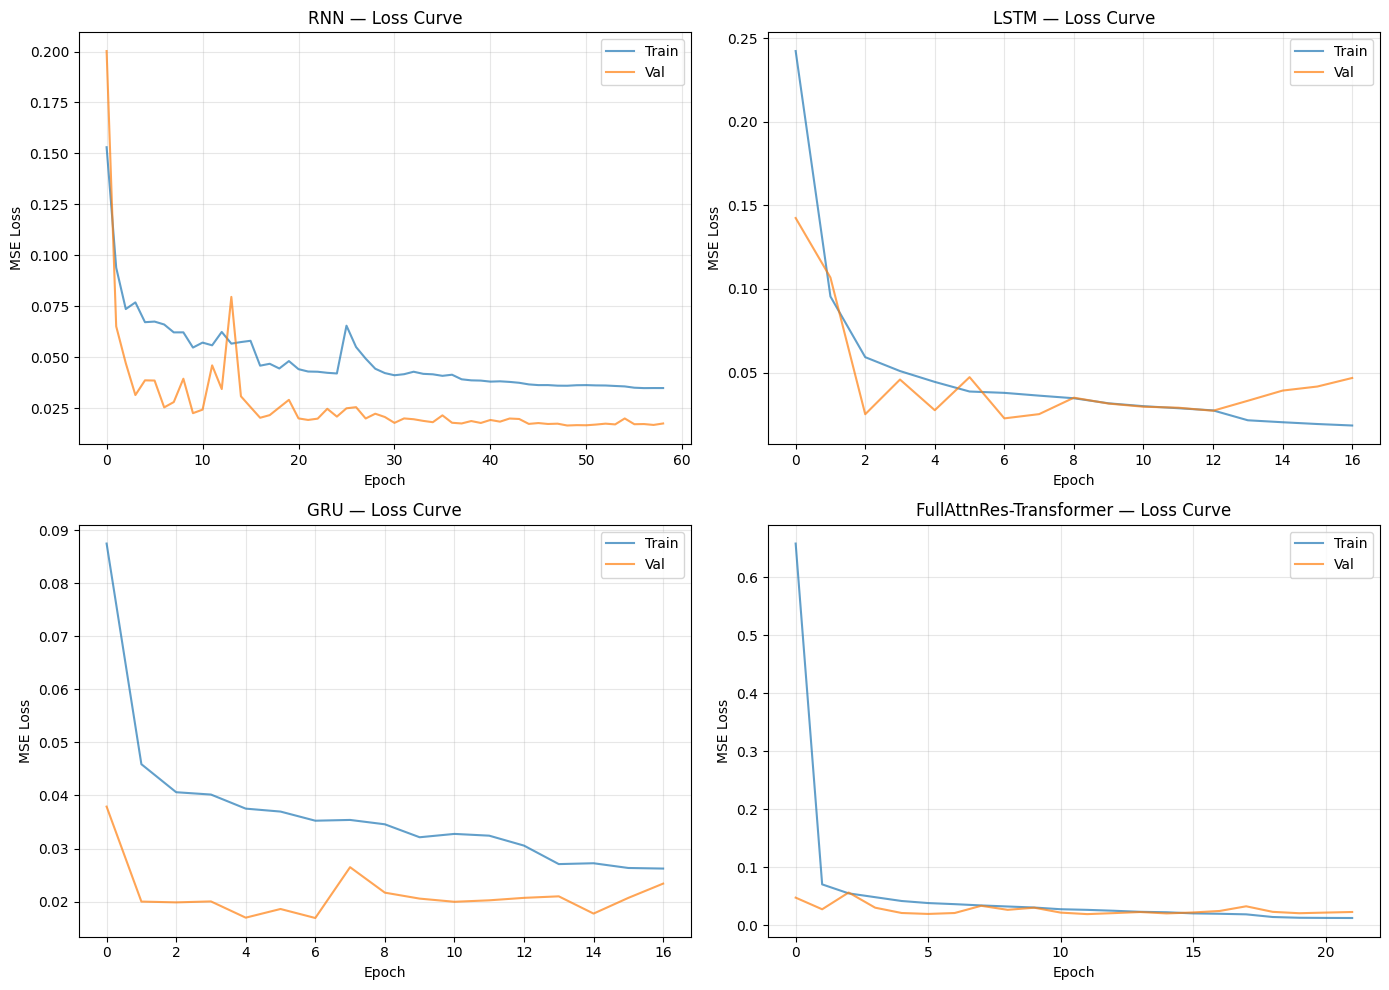

In [30]:
import matplotlib.pyplot as plt
# ============================================================
# PLOT TRAINING CURVES (from saved histories)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, hist) in enumerate(loaded_histories.items()):
    ax = axes[idx]
    ax.plot(hist['train_loss'], label='Train', alpha=0.7)
    ax.plot(hist['val_loss'], label='Val', alpha=0.7)
    ax.set_title(f'{name} — Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{image_path}/training_curves_loaded_{INPUT_LEN}-{PRED_HORIZON}.png', dpi=150)
plt.show()

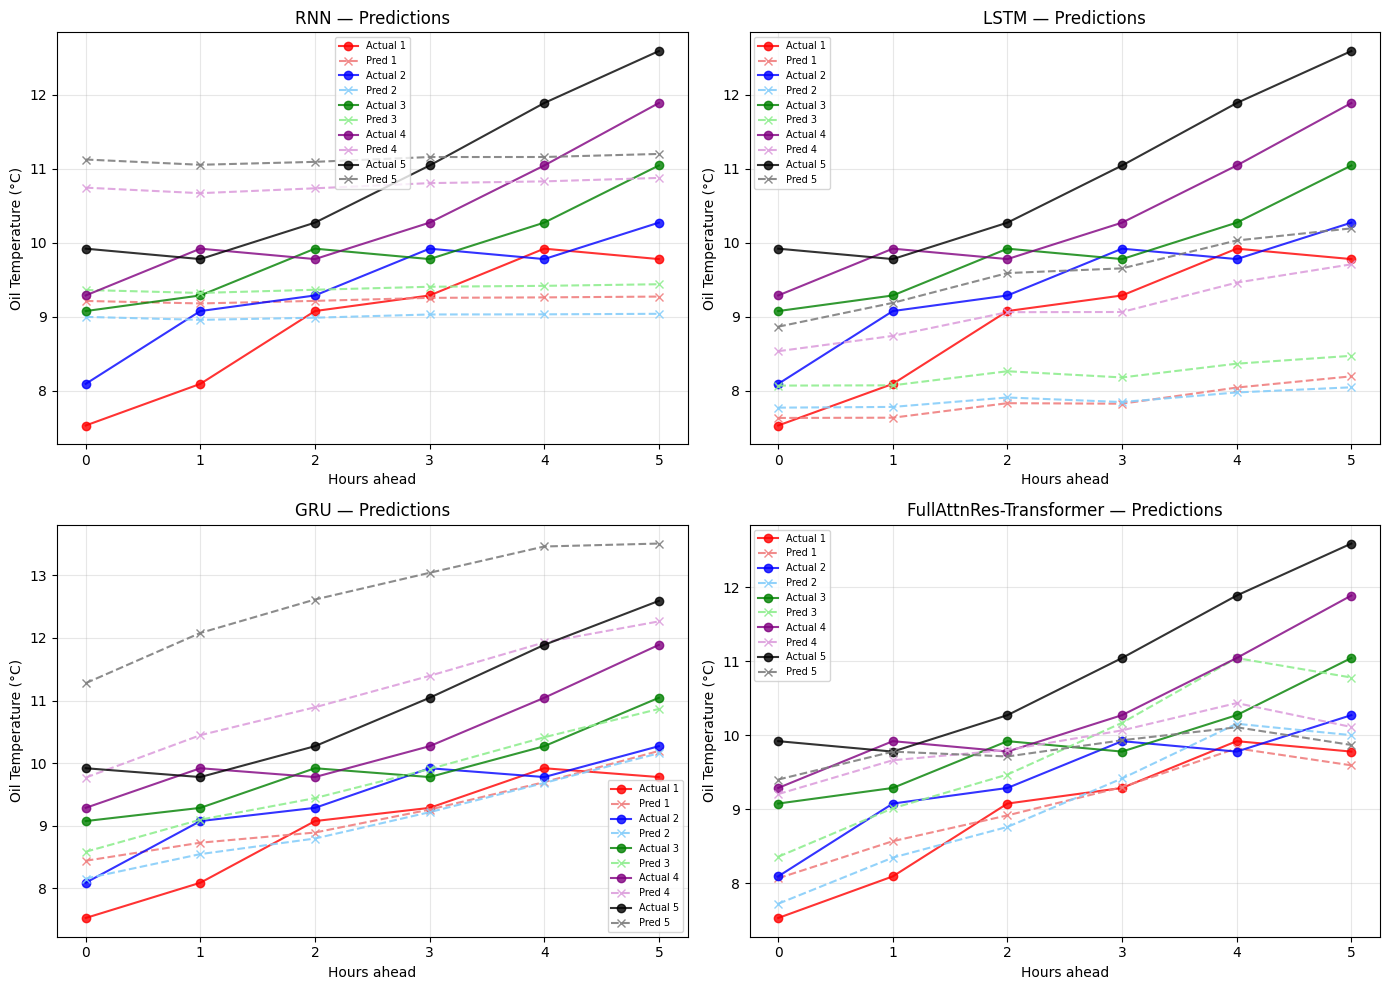

In [35]:
# ============================================================
# PLOT PREDICTIONS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

line_colors = [('red', 'lightcoral'), ('blue', 'lightskyblue'),
               ('green', 'lightgreen'), ('purple', 'plum'),
               ('black', 'grey')]


for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]

    for i, (base_c, light_c) in enumerate(line_colors):
        ax.plot(
            res['actuals'][i],
            'o-',
            color=base_c,
            label=f'Actual {i+1}',
            alpha=0.8
        )

        ax.plot(
            res['predictions'][i],
            'x--',
            color=light_c,
            label=f'Pred {i+1}',
            alpha=0.9
        )

    ax.set_title(f'{name} — Predictions')
    ax.set_xlabel('Hours ahead')
    ax.set_ylabel('Oil Temperature (°C)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{image_path}/predictions_comparison_loaded_{INPUT_LEN}-{PRED_HORIZON}.png', dpi=150)
plt.show()